# This is an 2D implementation of the Quickhull Algorithm in Python.

**This algorithm is used to find the convex hull of a set of points in a plane. It works by recursively dividing the point set into two subsets and finding the convex hull for each subset**

In [48]:
# Import Python Modules
import matplotlib.pyplot as plt
import math
import random

In [49]:
# Create points for quickhull implementation
n_points = 10
points = [(random.random(), random.random()) for _ in range(n_points)]

print(points)

x = [p[0] for p in points]
y = [p[1] for p in points]


[(0.15339217817361206, 0.0056563643582222545), (0.26830617846316995, 0.648055101901492), (0.6220549599715247, 0.44864952942140157), (0.7254748239191451, 0.47146584605406017), (0.19235143233178464, 0.8315799210524917), (0.8496473969288553, 0.01949902509368351), (0.1674015835764181, 0.22836659449383967), (0.7991218061965287, 0.4491728170220436), (0.41727962967773546, 0.47683217246527687), (0.11596516614545227, 0.8879610888979722)]


In [50]:

def perpendicular_distance(p1, p2, p):
    """
    Finds the distance from point p to the line that joins through points p1, p2. This is the determinant of the vectors

    Arguments:
        p1 -- point 1 [x1, y1]
        p2 -- point 2 [x2, y2]
        p  -- point to find distance to line [x, y]

    Return: Distance from point p to the line through p1 and p2
    """
    return (p[1] - p1[1]) * (p2[0] - p1[0]) - (p2[1] - p1[1]) * (p[0] - p1[0])
    

In [51]:
def find_outside_points(p1, p2, points):
        """
        Finds the points that outside the convex hull.
        Arguments:
            p1 -- point 1 [x1, y1]
            p2 -- point 2 [x2, y2]
            points -- list of points [[x1, y1], [x2, y2], ...]

        Return: A list of points that are outside the convex hull.
        """
        if not points:
            return []
        farthest_point = max(points, key=lambda p: abs(perpendicular_distance(p1, p2, p)))
        #Get rightmost points
        points1 = [p for p in points if perpendicular_distance(p1, farthest_point, p) > 0]
        #Get leftmost points
        points2 = [p for p in points if perpendicular_distance(farthest_point, p2, p) > 0]
        return find_outside_points(p1, farthest_point, points1) + [farthest_point] + find_outside_points(farthest_point, p2, points2)

In [52]:
def sort_points(points):
    """
    This sorts the convex hull points in a counter clockwise position to make sure the plot draws the convex hull accurately. This does not impact the quickhull algorithm in anyway,
    it is for visualisation on the graph
    
    Arguments:
        points - [(x1, y1), (x2, y2), ...] - The points from the convex hull
    Return: A list of points sorted in counter clockwise order
    """
    
    if len(points) <= 1:
        return points
    
    #Find the point closest to the centroid out of all the points to focus on
    centroid_x = sum(p[0] for p in points) / len(points)
    centroid_y = sum(p[1] for p in points) / len(points)

    def angle_from_centroid(point):
        #Calculating the angle between the point and the centroid, it does this for both centroid on each axis
        return math.atan2(point[1] - centroid_y, point[0] - centroid_x)
    return sorted(points, key=angle_from_centroid)

In [ ]:
# Quickhull Algorithm Implementation
def quickhull(points):
    """
    Quickhull algorithm to find the convex hull of a set of points in a 2D space.
    Arguments:
        points -- list of points [(x1, y1), (x2, y2), ...]
    Return: A list of points that represent the convex hull.
    """
    
    # Base Case
    if len(points) <= 2:
        return(points)
    
    min_point = min(points)
    max_point = max(points)
    hull = find_outside_points(min_point, max_point, points) + find_outside_points(max_point, min_point, points)
    return sort_points(set(hull))
    

5
5


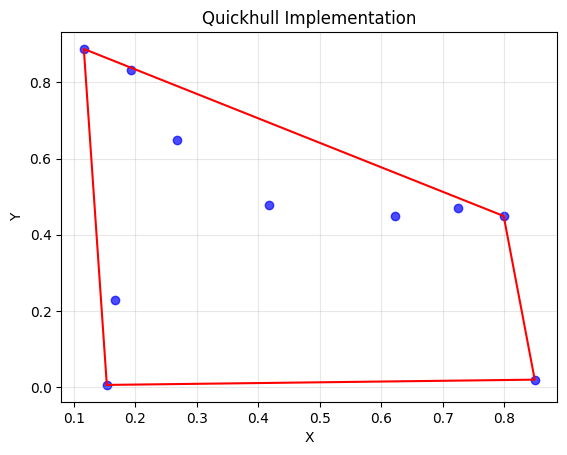

In [54]:
#Plotting the Convex Hull with all the points
convex_hull = quickhull(points)
convex_x = [p[0] for p in convex_hull]
convex_y = [p[1] for p in convex_hull]
convex_x.append(convex_x[0])
convex_y.append(convex_y[0])
print(len(convex_x))
print(len(convex_y))
plt.scatter(x, y, alpha = 0.7, color = "blue")
plt.plot(convex_x, convex_y, color = "red")
plt.title("Quickhull Implementation")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha = 0.3)
plt.show()     